╒════╤═════════════════╤═══════════╤═══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │    Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪═══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │  inf      │   inf       │ Air        │       0 │         8.979   │
│  1 │ Standard        │           │   20.1542 │     5       │ N-SK5      │       0 │         8.979   │
│  2 │ Standard        │           │ -123.64   │     5.1861  │ Air        │       0 │         7.36871 │
│  3 │ Stop - Standard │           │  -24.4077 │     2       │ N-F2       │       0 │         4.53246 │
│  4 │ Standard        │           │   17.674  │     6.93316 │ Air        │       0 │         4.83815 │
│  5 │ Standard        │           │   65.2851 │     3.5     │ S-PHM53    │       0 │         7.73158 │
│  6 │ Standard        │           │  -20.9164 │    39.5641  │ A

(<Figure size 2000x800 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

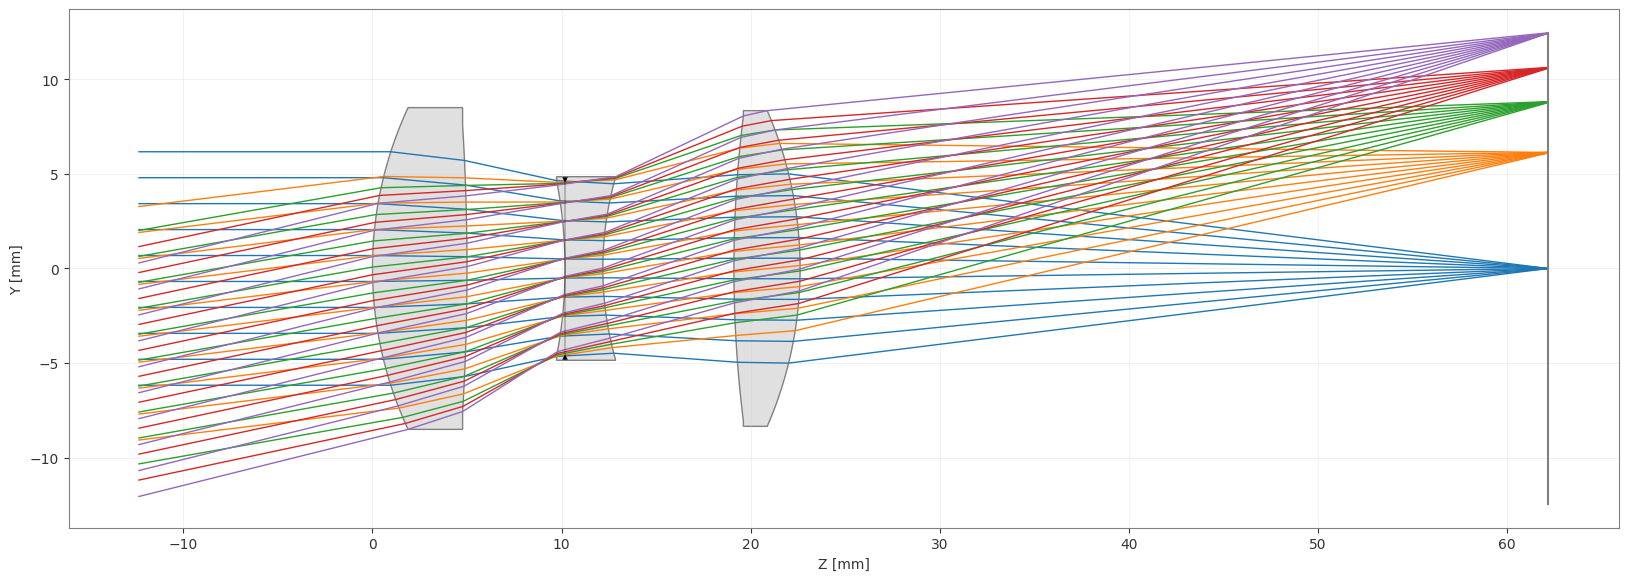

In [13]:
import numpy as np

from optiland import optic, analysis, optimization

lens = optic.Optic()

# define surfaces
lens.surfaces.add(index=0, radius=np.inf, thickness=np.inf)
lens.surfaces.add(index=1, material="N-SK5", radius=20.1542, thickness=5)
lens.surfaces.add(index=2, radius=-123.64,  thickness=5.1861)
lens.surfaces.add(index=3, is_stop=True, material="N-F2", radius=-24.4077,  thickness=2)
lens.surfaces.add(index=4, radius=17.674, thickness=6.93316)
lens.surfaces.add(index=5, material="S-PHM53", radius=65.2851, thickness=3.5)
lens.surfaces.add(index=6, radius=-20.9164,  thickness=39.5641)
lens.surfaces.add(index=7)

# define aperture
lens.set_aperture(aperture_type="EPD", value=12.35)

# define fields
lens.fields.set_type(field_type="angle")
lens.fields.add(y=0)
lens.fields.add(y=7)
lens.fields.add(y=10)
lens.fields.add(y=12)
lens.fields.add(y=14)

# define wavelengths
lens.wavelengths.add(value=0.486)
lens.wavelengths.add(value=0.588, is_primary=True)
lens.wavelengths.add(value=0.656)

# lens data
lens.info()

# view in 2D
lens.draw(num_rays=10, figsize=(20, 8))

In [14]:
print(f"Focal length: {lens.paraxial.f2():.3f} mm")
print(f"Image-space F-Number: {lens.paraxial.FNO():.3f}")

Focal length: 50.200 mm
Image-space F-Number: 4.065


(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Normalized Y Field Coordinate', ylabel='RMS Spot Size (mm)'>)

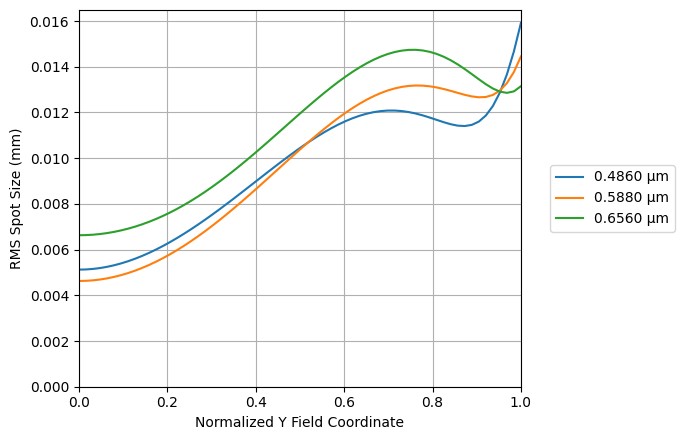

In [15]:
rms_vs_field = analysis.RmsSpotSizeVsField(lens)
rms_vs_field.view()

(<Figure size 1200x800 with 5 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.500'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.714'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 0.857'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

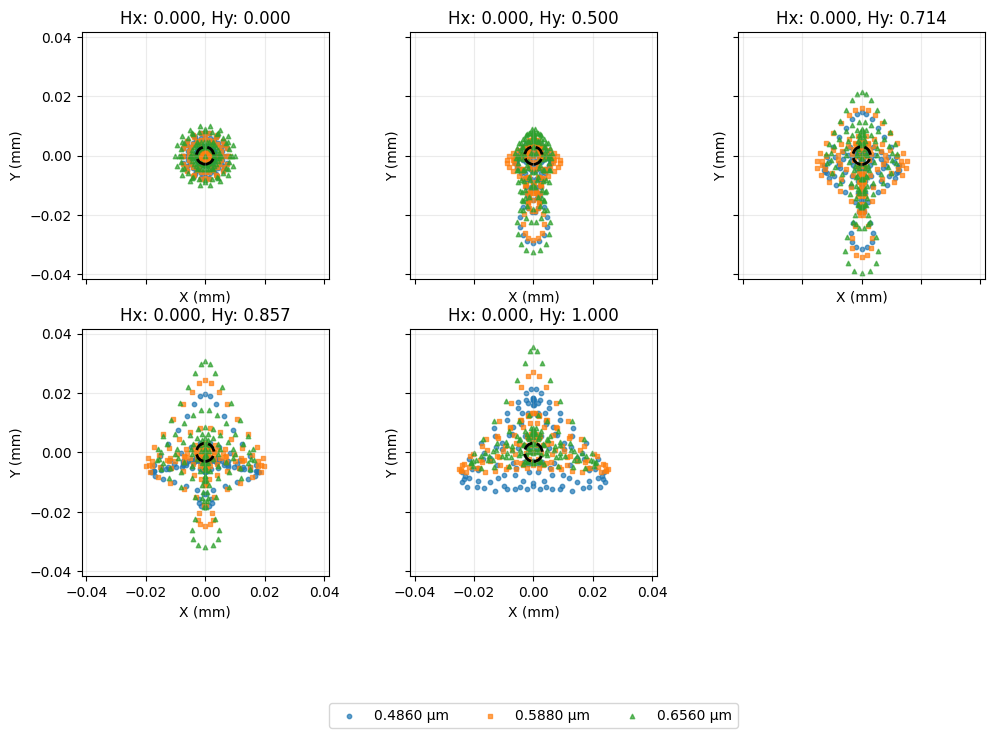

In [16]:
spot = analysis.SpotDiagram(lens)
spot.view(add_airy_disk=True)

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Grid Distortion (Max: 0.21%)'}, xlabel='Image X (mm)', ylabel='Image Y (mm)'>)

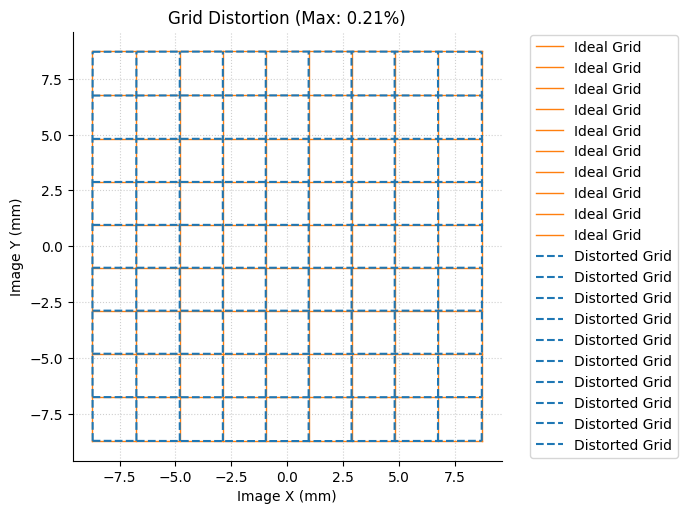

In [17]:
grid_distortion = analysis.GridDistortion(lens)
grid_distortion.view()

In [18]:
fields = lens.fields.get_field_coords()
wavelengths = lens.wavelengths.get_wavelengths()

rms_spot_radius = spot.rms_spot_radius()

weights = [1.0 for _ in fields]

M = 0.0

for i, field in enumerate(fields):
    for j, wavelength in enumerate(wavelengths):
        rms = rms_spot_radius[i][j]

        # Normalize
        normalized = rms / 0.025

        contribution = weights[i] * (normalized ** 2)
        M += contribution

        print(
            f"Field {field[1]:0.3f}, Wavelength {wavelength:.3f} µm, "
            f"RMS: {rms:.4f} mm, Contribution: {contribution:.4f}"
        )

print(f"\nMerit M = {M:.4f}")

Field 0.000, Wavelength 0.486 µm, RMS: 0.0051 mm, Contribution: 0.0420
Field 0.000, Wavelength 0.588 µm, RMS: 0.0046 mm, Contribution: 0.0342
Field 0.000, Wavelength 0.656 µm, RMS: 0.0066 mm, Contribution: 0.0703
Field 0.500, Wavelength 0.486 µm, RMS: 0.0104 mm, Contribution: 0.1745
Field 0.500, Wavelength 0.588 µm, RMS: 0.0104 mm, Contribution: 0.1723
Field 0.500, Wavelength 0.656 µm, RMS: 0.0120 mm, Contribution: 0.2286
Field 0.714, Wavelength 0.486 µm, RMS: 0.0121 mm, Contribution: 0.2337
Field 0.714, Wavelength 0.588 µm, RMS: 0.0131 mm, Contribution: 0.2726
Field 0.714, Wavelength 0.656 µm, RMS: 0.0146 mm, Contribution: 0.3432
Field 0.857, Wavelength 0.486 µm, RMS: 0.0114 mm, Contribution: 0.2088
Field 0.857, Wavelength 0.588 µm, RMS: 0.0129 mm, Contribution: 0.2645
Field 0.857, Wavelength 0.656 µm, RMS: 0.0141 mm, Contribution: 0.3182
Field 1.000, Wavelength 0.486 µm, RMS: 0.0159 mm, Contribution: 0.4055
Field 1.000, Wavelength 0.588 µm, RMS: 0.0145 mm, Contribution: 0.3342
Field 